In [1]:
import feedparser
import requests
import re
url = "https://www.cert.ssi.gouv.fr/feed/"
rss_feed = feedparser.parse(url)
for entry in rss_feed.entries:
    print("Titre :", entry.title)
    print("Description:", entry.description)
    print("Lien :", entry.link)
    print("Date :", entry.published)

Titre : [Màj] Vulnérabilité dans Microsoft Exchange Server (15 mai 2026)
Description: [Mise à jour du 11 juin 2026] Le 9 juin 2026, Microsoft a publié des versions correctives. [Publication initiale] Le 14 mai 2026, Microsoft a publié un avis de sécurité concernant la vulnérabilité CVE-2026-42897 affectant Exchange Server. Elle permet à un attaquant non authentifié de provoquer...
Lien : https://www.cert.ssi.gouv.fr/alerte/CERTFR-2026-ALE-005/
Date : Fri, 15 May 2026 00:00:00 +0000
Titre : Vulnérabilité dans Cisco Catalyst SD-WAN (05 juin 2026)
Description: Une vulnérabilité a été découverte dans Cisco Catalyst SD-WAN. Elle permet à un attaquant de provoquer une élévation de privilèges. Cisco indique que la vulnérabilité CVE-2026-20245 est activement exploitée.
Lien : https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-AVI-0699/
Date : Fri, 05 Jun 2026 00:00:00 +0000
Titre : Multiples vulnérabilités dans les produits SAP (09 juin 2026)
Description: De multiples vulnérabilités ont été découve

In [2]:
urls_json = []
res=[]
for entry in rss_feed.entries:
    urls_json.append(entry.link+"json/")
for url in urls_json:
    response = requests.get(url)

    if response.status_code == 404:
        print(f"Pas de JSON pour : {url}")
        continue

    if response.status_code != 200:
        print(f"Erreur {response.status_code} pour : {url}")
        continue

    if not response.text.strip():
        print(f"Réponse vide pour : {url}")
        continue

    try:
        data = response.json()
    except Exception as e:
        print(f"JSON invalide pour {url} : {e}")
        continue

    response = requests.get(url)
    data = response.json()
    #Extraction des CVE reference dans la clé cves du dict data
    ref_cves = data.get("cves", [])
    #attention il s’agit d’une liste des dictionnaires avec name et url comme clés
    print( "CVE référencés ", ref_cves)
    # Extraction des CVE avec une regex
    cve_pattern = r"CVE-\d{4}-\d{4,7}"
    cve_list = set(re.findall(cve_pattern, str(data)))
    for cve in cve_list:
         print(f"  - {cve}")
    res.append(cve_list)
print(res)


CVE référencés  [{'name': 'CVE-2026-42897', 'url': 'https://www.cve.org/CVERecord?id=CVE-2026-42897'}]
  - CVE-2026-42897
CVE référencés  [{'name': 'CVE-2026-20245', 'url': 'https://www.cve.org/CVERecord?id=CVE-2026-20245'}]
  - CVE-2026-20245
CVE référencés  [{'name': 'CVE-2026-44746', 'url': 'https://www.cve.org/CVERecord?id=CVE-2026-44746'}, {'name': 'CVE-2026-44750', 'url': 'https://www.cve.org/CVERecord?id=CVE-2026-44750'}, {'name': 'CVE-2026-44743', 'url': 'https://www.cve.org/CVERecord?id=CVE-2026-44743'}, {'name': 'CVE-2026-44755', 'url': 'https://www.cve.org/CVERecord?id=CVE-2026-44755'}, {'name': 'CVE-2026-44754', 'url': 'https://www.cve.org/CVERecord?id=CVE-2026-44754'}, {'name': 'CVE-2026-29145', 'url': 'https://www.cve.org/CVERecord?id=CVE-2026-29145'}, {'name': 'CVE-2026-44751', 'url': 'https://www.cve.org/CVERecord?id=CVE-2026-44751'}, {'name': 'CVE-2026-44757', 'url': 'https://www.cve.org/CVERecord?id=CVE-2026-44757'}, {'name': 'CVE-2026-27671', 'url': 'https://www.cve.

In [3]:
import time

def get_cvss_cwe(cve_id):
    try:
        url = f"https://cveawg.mitre.org/api/cve/{cve_id}"
        response = requests.get(url, timeout=10)
        if response.status_code != 200:
            return None, None, None
        data = response.json()
        cna = data["containers"]["cna"]

        try:
            description = cna["descriptions"][0]["value"]
        except:
            description = "Non disponible"

        cvss_score = None
        try:
            metrics = cna.get("metrics", [{}])[0]
            for key in ["cvssV3_1", "cvssV3_0", "cvssV2_0"]:
                if key in metrics:
                    cvss_score = metrics[key]["baseScore"]
                    break
        except:
            pass

        cwe = "Non disponible"
        try:
            problemtype = cna.get("problemTypes", [])
            if problemtype and "descriptions" in problemtype[0]:
                cwe = problemtype[0]["descriptions"][0].get("cweId", "Non disponible")
        except:
            pass

        return description, cvss_score, cwe

    except Exception as e:
        print(f"Erreur MITRE pour {cve_id} : {e}")
        return None, None, None


def get_epss(cve_id):
    try:
        url = f"https://api.first.org/data/v1/epss?cve={cve_id}"
        response = requests.get(url, timeout=10)
        data = response.json()
        epss_data = data.get("data", [])
        if epss_data:
            return float(epss_data[0]["epss"])
        return None
    except Exception as e:
        print(f"Erreur EPSS pour {cve_id} : {e}")
        return None


all_cves = set()
for cve_set in res:
    all_cves.update(cve_set)

print(f"Total CVE uniques à enrichir : {len(all_cves)}")

cve_enriched = {}

for cve_id in all_cves:
    print(f"Enrichissement de {cve_id}...")
    description, cvss_score, cwe = get_cvss_cwe(cve_id)
    epss_score = get_epss(cve_id)
    cve_enriched[cve_id] = {
        "description": description,
        "cvss_score": cvss_score,
        "cwe": cwe,
        "epss_score": epss_score
    }
    time.sleep(0.2)

print("Enrichissement terminé.")

Total CVE uniques à enrichir : 1237
Enrichissement de CVE-2026-8571...
Enrichissement de CVE-2026-23151...
Enrichissement de CVE-2026-46011...
Enrichissement de CVE-2026-11131...
Enrichissement de CVE-2026-45604...
Enrichissement de CVE-2026-45839...
Enrichissement de CVE-2026-10011...
Enrichissement de CVE-2026-46058...
Enrichissement de CVE-2026-43958...
Enrichissement de CVE-2025-58181...
Enrichissement de CVE-2026-43013...
Enrichissement de CVE-2026-41003...
Enrichissement de CVE-2026-10004...
Enrichissement de CVE-2026-46196...
Enrichissement de CVE-2026-47292...
Enrichissement de CVE-2026-46109...
Enrichissement de CVE-2026-9110...
Enrichissement de CVE-2026-23146...
Enrichissement de CVE-2026-8566...
Enrichissement de CVE-2026-45643...
Enrichissement de CVE-2026-23093...
Enrichissement de CVE-2026-8509...
Enrichissement de CVE-2026-45597...
Enrichissement de CVE-2026-9752...
Enrichissement de CVE-2026-8546...
Enrichissement de CVE-2026-23011...
Enrichissement de CVE-2026-46075..

In [6]:
import pandas as pd

rows = []

for entry in rss_feed.entries:
    url_json = entry.link + "json/"
    
    try:
        response = requests.get(url_json, timeout=10)
        if response.status_code != 200:
            continue
        data = response.json()
    except:
        continue

    bulletin_id = data.get("id", "Non disponible")
    titre = entry.title.replace("\n", " ").replace("\r", " ")
    date_pub = entry.published
    lien = entry.link
    type_bulletin = "Alerte" if "alerte" in lien.lower() or "ale" in bulletin_id.lower() else "Avis"

    cve_pattern = r"CVE-\d{4}-\d{4,7}"
    cve_list = list(set(re.findall(cve_pattern, str(data))))

    if not cve_list:
        rows.append({
            "ID ANSSI": bulletin_id,
            "Titre": titre,
            "Type": type_bulletin,
            "Date": date_pub,
            "CVE": None,
            "CVSS Score": None,
            "CWE": None,
            "EPSS Score": None,
            "Description": None,
            "Lien": lien
        })
        continue

    for cve_id in cve_list:
        enriched = cve_enriched.get(cve_id, {})
        description = enriched.get("description")
        if description:
            description = description.replace("\n", " ").replace("\r", " ").replace(";", ",")
        rows.append({
            "ID ANSSI": bulletin_id,
            "Titre": titre,
            "Type": type_bulletin,
            "Date": date_pub,
            "CVE": cve_id,
            "CVSS Score": enriched.get("cvss_score"),
            "CWE": enriched.get("cwe"),
            "EPSS Score": enriched.get("epss_score"),
            "Description": description,
            "Lien": lien
        })

df = pd.DataFrame(rows)
print(df.head())
print(df.shape)

df.to_csv("anssi_cve_consolidated.csv", index=False, sep=";")
print("Fichier CSV exporté.")

         ID ANSSI                                              Titre    Type  \
0  Non disponible  [Màj] Vulnérabilité dans Microsoft Exchange Se...  Alerte   
1  Non disponible  Vulnérabilité dans Cisco Catalyst SD-WAN (05 j...    Avis   
2  Non disponible  Multiples vulnérabilités dans les produits SAP...    Avis   
3  Non disponible  Multiples vulnérabilités dans les produits SAP...    Avis   
4  Non disponible  Multiples vulnérabilités dans les produits SAP...    Avis   

                              Date             CVE  CVSS Score      CWE  \
0  Fri, 15 May 2026 00:00:00 +0000  CVE-2026-42897         8.1   CWE-79   
1  Fri, 05 Jun 2026 00:00:00 +0000  CVE-2026-20245         7.8  CWE-116   
2  Tue, 09 Jun 2026 00:00:00 +0000  CVE-2026-44755         4.3  CWE-346   
3  Tue, 09 Jun 2026 00:00:00 +0000  CVE-2026-44751         7.1  CWE-862   
4  Tue, 09 Jun 2026 00:00:00 +0000  CVE-2026-24315         4.2   CWE-35   

   EPSS Score                                        Description  \


In [16]:
#ETAPE 5 - Préparation ----------------------------------------------------------------------------
import pandas as pd
import warnings
warnings.filterwarnings('ignore')




df = pd.read_csv("anssi_cve_consolidated.csv", sep=";")
print(f"Forme du DataFrame: {df.shape}")
print(f"{df.columns.tolist()}")

print(df.dtypes)
print(df.head())



Forme du DataFrame: (1282, 10)
['ID ANSSI', 'Titre', 'Type', 'Date', 'CVE', 'CVSS Score', 'CWE', 'EPSS Score', 'Description', 'Lien']
ID ANSSI        object
Titre           object
Type            object
Date            object
CVE             object
CVSS Score     float64
CWE             object
EPSS Score     float64
Description     object
Lien            object
dtype: object
         ID ANSSI                                              Titre    Type  \
0  Non disponible  [Màj] Vulnérabilité dans Microsoft Exchange Se...  Alerte   
1  Non disponible  Vulnérabilité dans Cisco Catalyst SD-WAN (05 j...    Avis   
2  Non disponible  Multiples vulnérabilités dans les produits SAP...    Avis   
3  Non disponible  Multiples vulnérabilités dans les produits SAP...    Avis   
4  Non disponible  Multiples vulnérabilités dans les produits SAP...    Avis   

                              Date             CVE  CVSS Score      CWE  \
0  Fri, 15 May 2026 00:00:00 +0000  CVE-2026-42897         8.1   C

In [17]:
#Conversion de la colonne Date en datetime
df['Date'] = pd.to_datetime(df['Date'], format='%a, %d %b %Y %H:%M:%S %z', errors='coerce')
print(f"Date minimale: {df['Date'].min()}")
print(f"Date maximale: {df['Date'].max()}")
print(f"Nombre de dates invalides: {df['Date'].isna().sum()}")
print(f"\nTypes après conversion:\n{df.dtypes}")

Date minimale: 2026-05-15 00:00:00+00:00
Date maximale: 2026-06-12 00:00:00+00:00
Nombre de dates invalides: 0

Types après conversion:
ID ANSSI                    object
Titre                       object
Type                        object
Date           datetime64[ns, UTC]
CVE                         object
CVSS Score                 float64
CWE                         object
EPSS Score                 float64
Description                 object
Lien                        object
dtype: object


In [18]:
#Création de la colonne de sévérité CVSS

def categorize_cvss(score):
    if pd.isna(score):
        return "Non disponible"
    elif score < 4.0:
        return "Faible (0-3.9)"
    elif score < 7.0:
        return "Moyenne (4-6.9)"
    elif score < 9.0:
        return "Élevée (7-8.9)"
    else:
        return "Critique (9-10)"

df['CVSS Severity'] = df['CVSS Score'].apply(categorize_cvss)
print(df['CVSS Severity'].value_counts())
print(f"\nTaux de valeurs manquantes CVSS: {df['CVSS Score'].isna().sum() / len(df) * 100:.2f}%")

CVSS Severity
Non disponible     753
Élevée (7-8.9)     353
Moyenne (4-6.9)    108
Critique (9-10)     50
Faible (0-3.9)      18
Name: count, dtype: int64

Taux de valeurs manquantes CVSS: 58.74%


In [19]:
#Vérification des scores EPSS

epss_clean = df['EPSS Score'].dropna()
print(f"Nombre de scores EPSS disponibles: {len(epss_clean)}")
print(f"Taux de disponibilité: {len(epss_clean)/len(df)*100:.2f}%")
print(f"Moyenne EPSS: {epss_clean.mean():.6f}")
print(f"Médiane EPSS: {epss_clean.median():.6f}")
print(f"EPSS minimum: {epss_clean.min():.6f}")
print(f"EPSS maximum: {epss_clean.max():.6f}")

Nombre de scores EPSS disponibles: 1270
Taux de disponibilité: 99.06%
Moyenne EPSS: 0.001885
Médiane EPSS: 0.000350
EPSS minimum: 0.000030
EPSS maximum: 0.479100


In [20]:
#Aperçu final
print(f"Dimensions: {df.shape}")
print(f"\nColonnes: {df.columns.tolist()}")
print(f"\nStatistiques descriptives des colonnes numériques:")
print(df[['CVSS Score', 'EPSS Score']].describe())
print(f"\n5 dernières lignes:")
print(df.tail())

Dimensions: (1282, 11)

Colonnes: ['ID ANSSI', 'Titre', 'Type', 'Date', 'CVE', 'CVSS Score', 'CWE', 'EPSS Score', 'Description', 'Lien', 'CVSS Severity']

Statistiques descriptives des colonnes numériques:
       CVSS Score   EPSS Score
count  529.000000  1270.000000
mean     7.350473     0.001885
std      1.458986     0.019819
min      2.600000     0.000030
25%      7.000000     0.000200
50%      7.800000     0.000350
75%      8.000000     0.000730
max     10.000000     0.479100

5 dernières lignes:
            ID ANSSI                                              Titre  Type  \
1277  Non disponible  Multiples vulnérabilités dans les produits Net...  Avis   
1278  Non disponible  Multiples vulnérabilités dans les produits Net...  Avis   
1279  Non disponible  Multiples vulnérabilités dans les produits Net...  Avis   
1280  Non disponible  Vulnérabilité dans les produits Moxa (12 juin ...  Avis   
1281  Non disponible          Vulnérabilité dans MongoDB (12 juin 2026)  Avis   

       

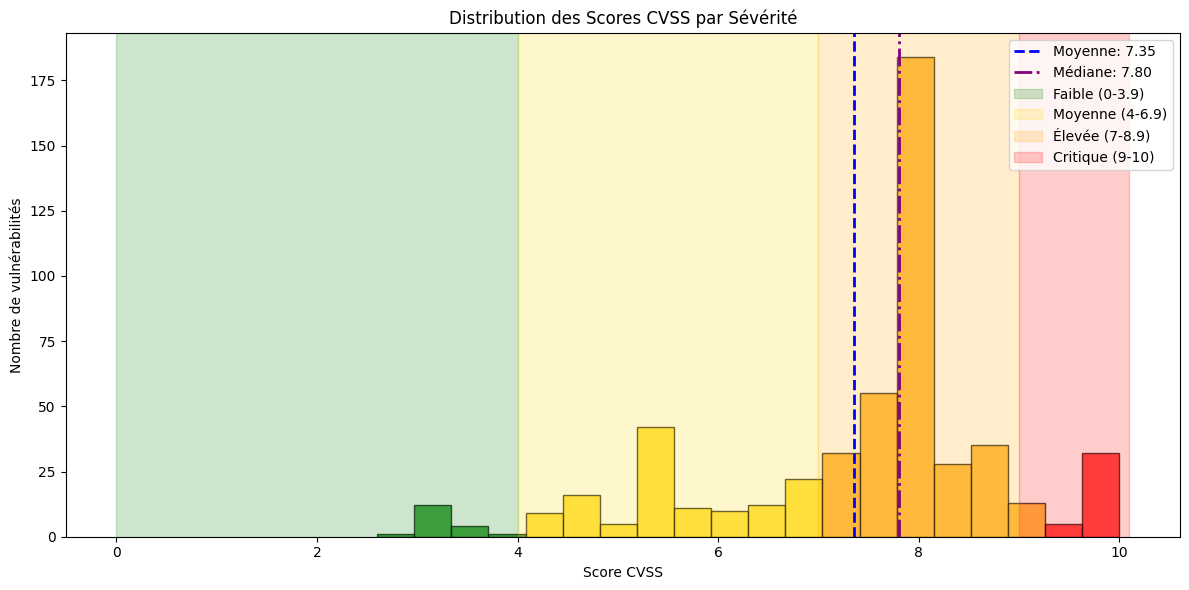

Nombre de valeurs disponibles: 529/1282 (41.3%)
Moyenne: 7.35
Médiane: 7.80
Écart-type: 1.46
Minimum: 2.60
Maximum: 10.00


In [21]:
#TOUJOURS ETAPE 5 - Visualisation -----------------------------------------------

#Histogramme des scores CVSS avec couleurs par sévérité

import matplotlib.pyplot as plt

cvss_clean = df[df['CVSS Score'].notna()]['CVSS Score']                         #Pour garder que les valeurs non null


def get_color(score):
    if score < 4.0:
        return 'green'
    elif score < 7.0:
        return 'gold'
    elif score < 9.0:
        return 'orange'
    else:
        return 'red'

#Historigramme = .hist
fig, ax = plt.subplots(figsize=(12, 6))                                         #fig = l'onglet, axe = la où ce sera dessiné, figsize = 12 pouces x 6 pouces

n, bins, patches = ax.hist(cvss_clean, bins=20, edgecolor='black', alpha=0.7)   # n = nb vulnérabilités pour chaque interval, bins = les barres sur l'axe X, patches = couleurs
                                                                                #Ici on prend les données = cvss_clean, 20 intervalles (bars) = bins, - , alpha = transparence



for patch, left_edge in zip(patches, bins[:-1]):                                #zip = créer une liste de tuples avec [(patches[0], bins[0]), ([1], [1]), ...]
    if left_edge < 4.0:
        patch.set_facecolor('green')                                            #Si la barre commence avant 4
    elif left_edge < 7.0:
        patch.set_facecolor('gold')                                             #" entre 4 et 7
    elif left_edge < 9.0:
        patch.set_facecolor('orange')                                           #" entre 7 et 9
    else:
        patch.set_facecolor('red')                                              #au delà



#Lignes verticales pour la moyenne et la médiane avec axvline : Axe X + Vertical + line (ligne verticale sur l'axe X)
ax.axvline(x=cvss_clean.mean(), color='blue', linestyle='--', linewidth=2, label=f'Moyenne: {cvss_clean.mean():.2f}')
ax.axvline(x=cvss_clean.median(), color='purple', linestyle='-.', linewidth=2, label=f'Médiane: {cvss_clean.median():.2f}')

#axvspan = Axe X - Vertical SPAN (étendue verticale)
ax.axvspan(0, 4, alpha=0.2, color='green', label='Faible (0-3.9)')
ax.axvspan(4, 7, alpha=0.2, color='gold', label='Moyenne (4-6.9)')
ax.axvspan(7, 9, alpha=0.2, color='orange', label='Élevée (7-8.9)')
ax.axvspan(9, 10.1, alpha=0.2, color='red', label='Critique (9-10)')


ax.set_xlabel('Score CVSS')
ax.set_ylabel('Nombre de vulnérabilités')
ax.set_title('Distribution des Scores CVSS par Sévérité')
ax.legend(loc='upper right')


plt.tight_layout()
plt.show()

print(f"Nombre de valeurs disponibles: {len(cvss_clean)}/{len(df)} ({len(cvss_clean)/len(df)*100:.1f}%)")
print(f"Moyenne: {cvss_clean.mean():.2f}")
print(f"Médiane: {cvss_clean.median():.2f}")
print(f"Écart-type: {cvss_clean.std():.2f}")
print(f"Minimum: {cvss_clean.min():.2f}")
print(f"Maximum: {cvss_clean.max():.2f}")

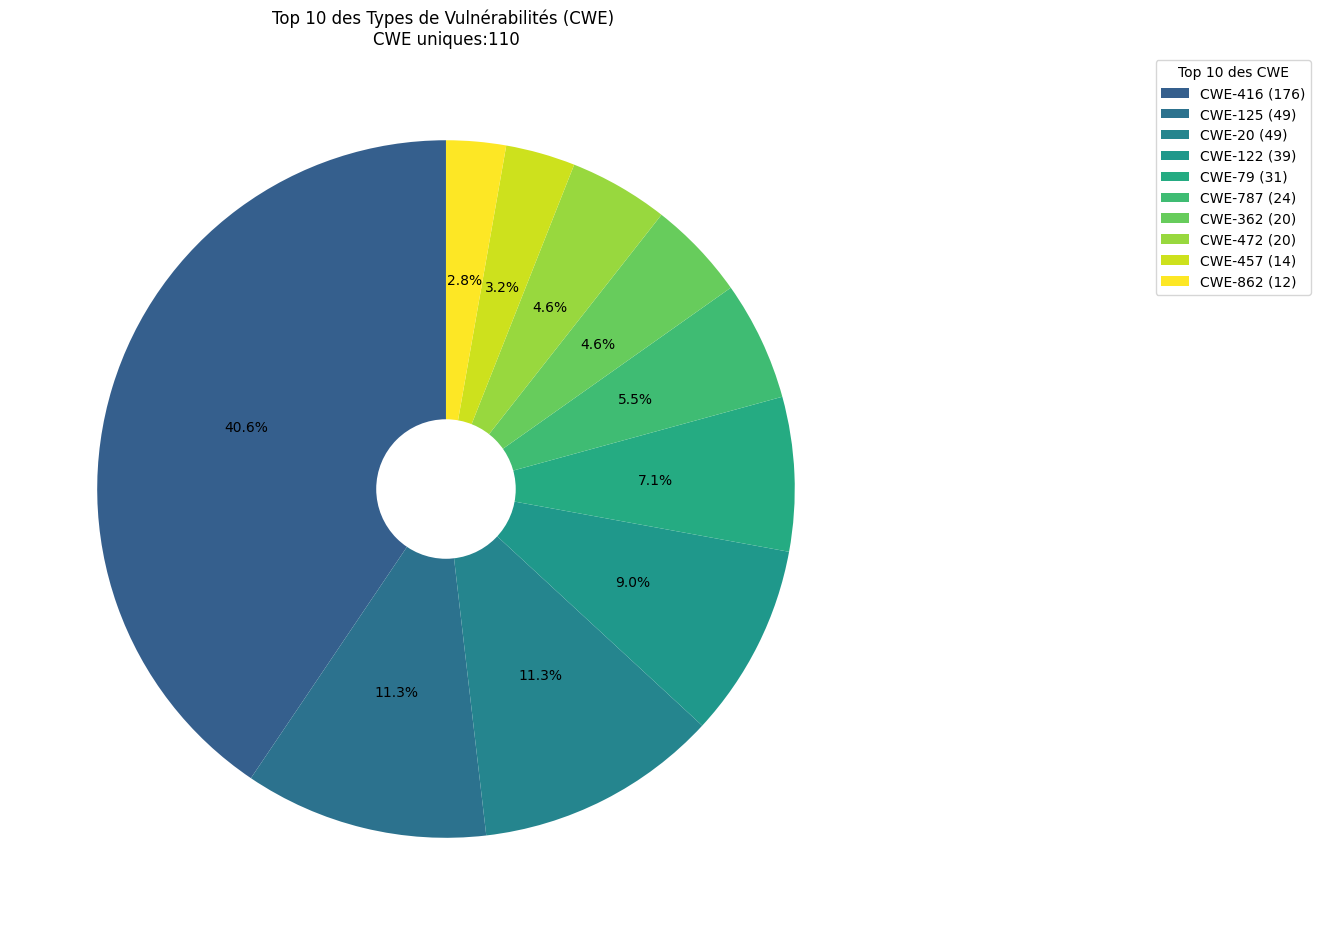

Nombre total de CVE avec CWE: 718/1282
Nombre de CWE uniques: 110

Top 5 des CWE:
   1. CWE-416: 176 occurrences (24.5%)
   2. CWE-125: 49 occurrences (6.8%)
   3. CWE-20: 49 occurrences (6.8%)
   4. CWE-122: 39 occurrences (5.4%)
   5. CWE-79: 31 occurrences (4.3%)


In [22]:
#Diagramme circulaire des types CWE
import matplotlib.pyplot as plt
import numpy as np

cwe_counts = df[df['CWE'] != 'Non disponible']['CWE'].value_counts().head(10)           #Compter les occurrences de chaque CWE


cwe_labels = []
for cwe, count in zip(cwe_counts.index, cwe_counts.values):                             #Zip = créer une liste de tuples avec [(cwe_counts.index[0], cwe_counts.values[0]), ([1], [1]), ...]
    if len(cwe) > 25:                                                                   #Afficher CWE-ID et le nombre
        cwe_labels.append(f"{cwe}\n({count})")
    else:
        cwe_labels.append(f"{cwe} ({count})")



colors = plt.cm.viridis(np.linspace(0.3, 1, len(cwe_counts)))                           #Palette un peu cute ^w^ = dégradé de couleurs (bleu → vert → jaune)


fig, ax = plt.subplots(figsize=(12, 10))                                                #12 pouces x 10 pouces


wedges, texts, autotexts = ax.pie(                                                      #.pie = camember, wedges = nb parts dans le camember,texts = étiquettes, autotexts = poucentages
    cwe_counts.values,                                                                  #Taille de chaque part
    labels=None,                                                                        #Pas de labels directement sur le pie -> sur le côté
    autopct='%1.1f%%',                                                                  #Format des pourcentages 
    startangle=90,                                                                      #Commencer à 90° (en haut)
    colors=colors
)


ax.legend(wedges, cwe_labels, title="Top 10 des CWE", bbox_to_anchor=(1, 0, 0.5, 1))

centre_circle = plt.Circle((0, 0), 0.20, fc='white', linewidth=1.25)                    #C'est plus joli comme ça
fig.gca().add_artist(centre_circle)


total_cwe_types = df[df['CWE'] != 'Non disponible']['CWE'].nunique()
total_cve_with_cwe = len(df[df['CWE'] != 'Non disponible'])

ax.set_title(f'Top 10 des Types de Vulnérabilités (CWE) \nCWE uniques:{total_cwe_types}')

plt.tight_layout()
plt.show()


print(f"Nombre total de CVE avec CWE: {len(df[df['CWE'] != 'Non disponible'])}/{len(df)}")
print(f"Nombre de CWE uniques: {df[df['CWE'] != 'Non disponible']['CWE'].nunique()}")
print("\nTop 5 des CWE:")
for i, (cwe, count) in enumerate(cwe_counts.head(5).items(), 1):
    percentage = count / len(df[df['CWE'] != 'Non disponible']) * 100
    print(f"   {i}. {cwe}: {count} occurrences ({percentage:.1f}%)")

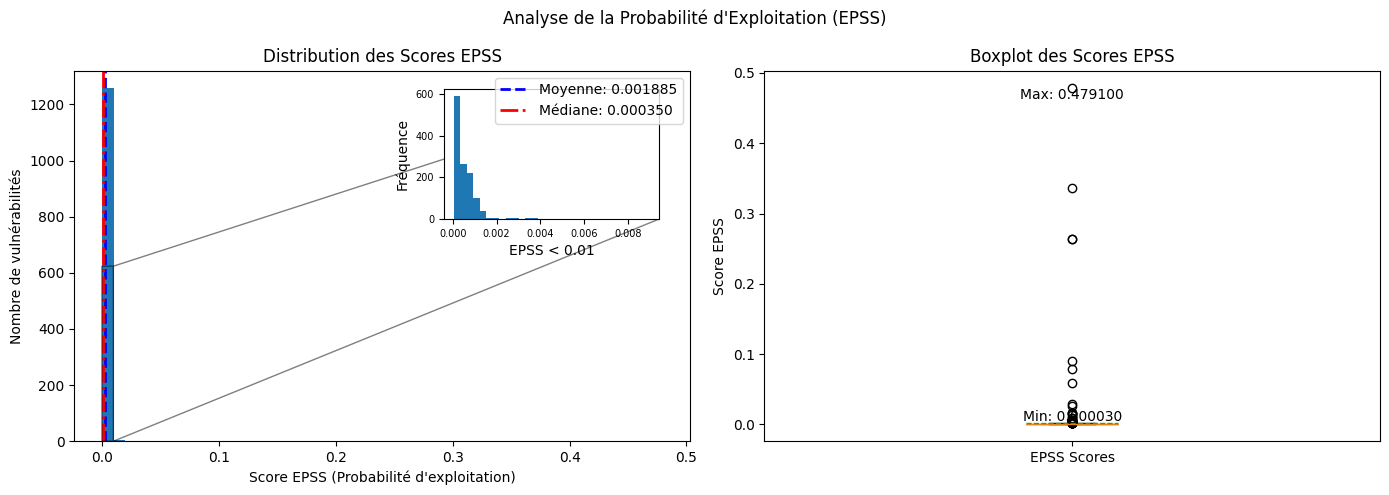

Nombre de valeurs disponibles: 1270/1282 (99.1%)
Moyenne: 0.001885
Médiane: 0.000350
Écart-type: 0.019819
Minimum: 0.000030
Maximum: 0.479100
90ème percentile: 0.001152
95ème percentile: 0.001428

Vulnérabilités avec EPSS > 0.1 (haut risque): 4
   Soit 0.31% du total


In [23]:
#Courbe de distribution des scores EPSS

import matplotlib.pyplot as plt

epss_clean = df[df['EPSS Score'].notna()]['EPSS Score']                                             #Filtrer les valeurs non nulles


fig, axes = plt.subplots(1, 2, figsize=(14, 5))                                                     #Créer une fig avec deux subplot

#Histogramme de distribution
n, bins, patches = axes[0].hist(epss_clean, bins=50)
axes[0].set_xlabel('Score EPSS (Probabilité d\'exploitation)')
axes[0].set_ylabel('Nombre de vulnérabilités')
axes[0].set_title('Distribution des Scores EPSS')

#Ligne moyenne et médiane
axes[0].axvline(x=epss_clean.mean(), color='blue', linestyle='--', linewidth=2, label=f'Moyenne: {epss_clean.mean():.6f}')
axes[0].axvline(x=epss_clean.median(), color='red', linestyle='-.', linewidth=2, label=f'Médiane: {epss_clean.median():.6f}')
axes[0].legend(loc='upper right')

#Zoom sur la zone 0 - 600
inset_ax = axes[0].inset_axes([0.6, 0.6, 0.35, 0.35])
epss_low = epss_clean[epss_clean < 0.01]
inset_ax.hist(epss_low, bins=30)
inset_ax.set_xlabel('EPSS < 0.01')
inset_ax.set_ylabel('Fréquence')
inset_ax.tick_params(labelsize=7)
axes[0].indicate_inset_zoom(inset_ax, edgecolor="black")




#Boxplot
boxplot_data = [epss_clean]
bp = axes[1].boxplot(boxplot_data, vert=True, patch_artist=True, showmeans=True, meanline=True)
bp['boxes'][0].set_facecolor('teal')
bp['boxes'][0].set_alpha(0.7)
axes[1].set_ylabel('Score EPSS')
axes[1].set_title('Boxplot des Scores EPSS')
axes[1].set_xticklabels(['EPSS Scores'])

#Annotation Boxplot
axes[1].text(1, epss_clean.min(), f'Min: {epss_clean.min():.6f}', ha='center', va='bottom')
axes[1].text(1, epss_clean.max(), f'Max: {epss_clean.max():.6f}', ha='center', va='top')

plt.suptitle('Analyse de la Probabilité d\'Exploitation (EPSS)')
plt.tight_layout()
plt.show()




print(f"Nombre de valeurs disponibles: {len(epss_clean)}/{len(df)} ({len(epss_clean)/len(df)*100:.1f}%)")
print(f"Moyenne: {epss_clean.mean():.6f}")
print(f"Médiane: {epss_clean.median():.6f}")
print(f"Écart-type: {epss_clean.std():.6f}")
print(f"Minimum: {epss_clean.min():.6f}")
print(f"Maximum: {epss_clean.max():.6f}")
print(f"90ème percentile: {epss_clean.quantile(0.9):.6f}")
print(f"95ème percentile: {epss_clean.quantile(0.95):.6f}")




# Analyse des vulnérabilités à haut risque EPSS
high_epss = epss_clean[epss_clean > 0.1]
if len(high_epss) > 0:
    print(f"\nVulnérabilités avec EPSS > 0.1 (haut risque): {len(high_epss)}")
    print(f"   Soit {len(high_epss)/len(epss_clean)*100:.2f}% du total")
else:
    print("\nAucune vulnérabilité avec EPSS > 0.1")

 1. Microsoft            :  460 occurrences (35.88%)
 2. Linux                :  330 occurrences (25.74%)
 3. Palo Alto            :  253 occurrences (19.73%)
 4. Splunk               :   43 occurrences ( 3.35%)
 5. Spring               :   29 occurrences ( 2.26%)
 6. Google               :   28 occurrences ( 2.18%)
 7. Adobe                :   27 occurrences ( 2.11%)
 8. OpenSSL              :   18 occurrences ( 1.40%)
 9. MongoDB              :   15 occurrences ( 1.17%)
10. SAP                  :   15 occurrences ( 1.17%)
11. GitLab               :   12 occurrences ( 0.94%)
12. IBM                  :   12 occurrences ( 0.94%)
13. Typo3                :   10 occurrences ( 0.78%)
14. Xen                  :    5 occurrences ( 0.39%)
15. NetApp               :    4 occurrences ( 0.31%)


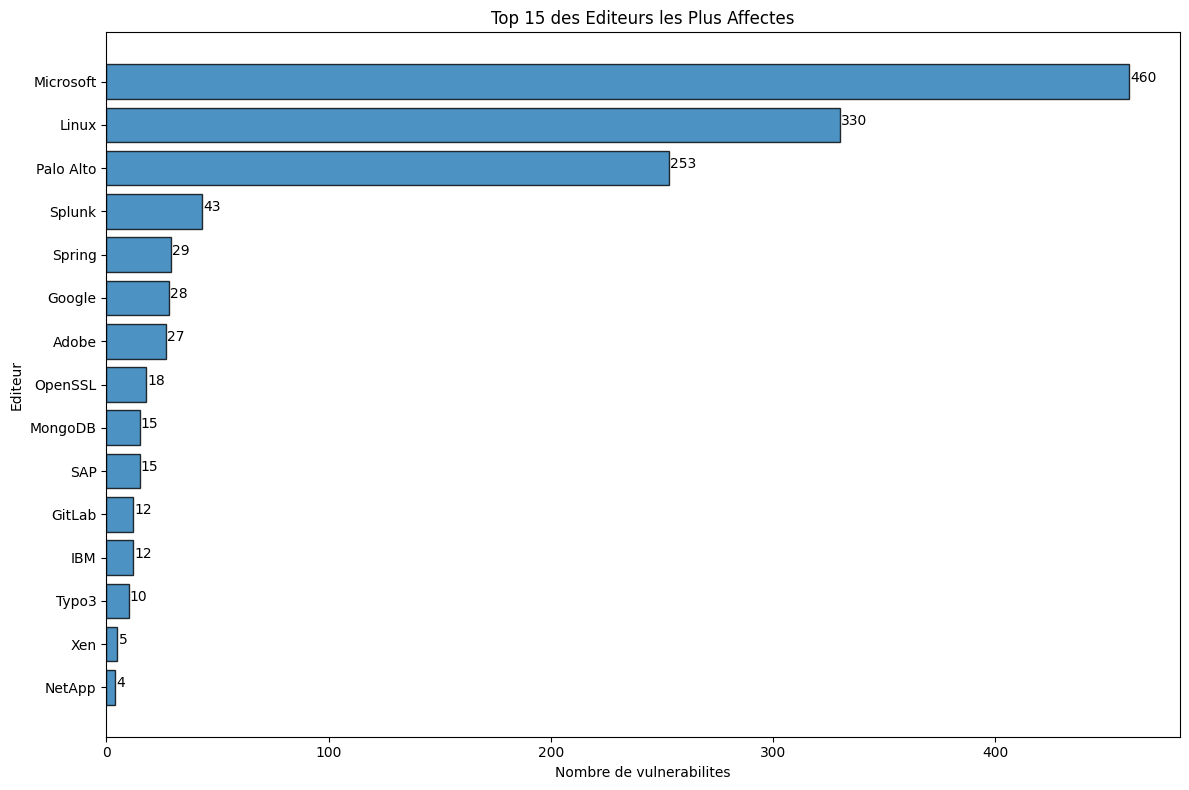

Nombre total d'editeurs distincts: 28
Top 3 represente: 81.4% des vulnerabilites
Nombre de vulnerabilites sans editeur identifie (Autre): 0


In [24]:
#Extraction des editeurs + classement

import pandas as pd
import matplotlib.pyplot as plt
import re


def extract_vendor_from_title(title):                                                                           #extraire l'editeur à partir du titre du bulletin
    title_lower = str(title).lower()
    
    #Liste des editeurs connus
    vendors = {
        'Microsoft': ['microsoft', 'windows', 'office', 'azure', '.net', 'exchange', 'edge'],
        'Cisco': ['cisco', 'catalyst', 'sd-wan'],
        'SAP': ['sap', 'business objects', 'fiori'],
        'Adobe': ['adobe', 'acrobat', 'reader', 'flash', 'photoshop'],
        'Google': ['google', 'chrome', 'android'],
        'Apple': ['apple', 'ios', 'macos', 'ipados', 'watchos', 'tvos'],
        'Linux': ['linux', 'kernel'],
        'Red Hat': ['red hat', 'rhel'],
        'Ubuntu': ['ubuntu', 'canonical'],
        'SUSE': ['suse'],
        'Oracle': ['oracle', 'mysql', 'java', 'peoplesoft'],
        'IBM': ['ibm'],
        'VMware': ['vmware', 'vcenter', 'esxi'],
        'Dell': ['dell', 'emc'],
        'HP': ['hp', 'hewlett packard'],
        'Intel': ['intel'],
        'AMD': ['amd'],
        'NVIDIA': ['nvidia'],
        'Samsung': ['samsung'],
        'Siemens': ['siemens'],
        'Schneider': ['schneider', 'ecostruxure'],
        'Fortinet': ['fortinet', 'fortigate'],
        'Ivanti': ['ivanti'],
        'MongoDB': ['mongodb'],
        'PostgreSQL': ['postgresql'],
        'Apache': ['apache', 'http server', 'tomcat'],
        'Nginx': ['nginx'],
        'OpenSSL': ['openssl'],
        'Spring': ['spring', 'spring boot', 'spring framework'],
        'Palo Alto': ['palo alto', 'pan-os'],
        'Splunk': ['splunk'],
        'GitLab': ['gitlab'],
        'NetApp': ['netapp'],
        'Moxa': ['moxa'],
        'Xen': ['xen'],
        'Typo3': ['typo3'],
        'Stormshield': ['stormshield'],
        'FreeBSD': ['freebsd'],
        'Veeam': ['veeam'],
        'Traefik': ['traefik'],
        'LibreNMS': ['librenms'],
        'F5': ['f5', 'big-ip'],
        'Juniper': ['juniper'],
        'Huawei': ['huawei'],
        'Zyxel': ['zyxel'],
        'Qualcomm': ['qualcomm'],
        'WordPress': ['wordpress'],
        'Drupal': ['drupal'],
        'Joomla': ['joomla']
    }
    
    for vendor, keywords in vendors.items():
        for keyword in keywords:
            if keyword in title_lower:
                return vendor
    return 'Autre'


df['Editeur'] = df['Titre'].apply(extract_vendor_from_title)                                                    #Appliquer l'extraction


vendor_counts = df['Editeur'].value_counts()                                                                    #compter les occurrences par editeur
top_vendors = vendor_counts.head(15)


for i, (vendor, count) in enumerate(top_vendors.items(), 1):
    percentage = count / len(df) * 100
    print(f"{i:2d}. {vendor:20s} : {count:4d} occurrences ({percentage:5.2f}%)")


fig, ax = plt.subplots(figsize=(12, 8))                                                                         #Barres horizontales 12 pouces x 8 pouces

bars = ax.barh(range(len(top_vendors)), top_vendors.values, edgecolor='black', alpha=0.8)                       #.barh = bar horizontal, range(len(top_vendors)) = position des barres sur l'axe Y, top_vendors.values = taille des barres

ax.set_yticks(range(len(top_vendors)))
ax.set_yticklabels(top_vendors.index)
ax.set_xlabel('Nombre de vulnerabilites')
ax.set_ylabel('Editeur')
ax.set_title('Top 15 des Editeurs les Plus Affectes')
ax.invert_yaxis()


for i, (bar, val) in enumerate(zip(bars, top_vendors.values)):                                                  # enumerate = pour avoir un compteur i
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, str(val))

plt.tight_layout()
plt.show()



print(f"Nombre total d'editeurs distincts: {df['Editeur'].nunique()}")
print(f"Top 3 represente: {(top_vendors.iloc[:3].sum() / len(df) * 100):.1f}% des vulnerabilites")
print(f"Nombre de vulnerabilites sans editeur identifie (Autre): {vendor_counts.get('Autre', 0)}")

In [ ]:
#Scatter plot CVSS vs EPSS (avec Plotly)
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

scatter_df = df[df['CVSS Score'].notna() & df['EPSS Score'].notna()].copy()

def get_severity_label(score):
    if score < 4.0:
        return 'Faible (0-3.9)'
    elif score < 7.0:
        return 'Moyenne (4-6.9)'
    elif score < 9.0:
        return 'Elevee (7-8.9)'
    else:
        return 'Critique (9-10)'

scatter_df['Severite'] = scatter_df['CVSS Score'].apply(get_severity_label)

print(f"Nombre de points pour le scatter plot: {len(scatter_df)}")

color_map = {
    'Critique (9-10)': 'red',
    'Elevee (7-8.9)': 'orange',
    'Moyenne (4-6.9)': 'gold',
    'Faible (0-3.9)': 'green'
}


fig = px.scatter(                                                                                   #px = plotly express
    scatter_df,                                                                                     #Données utilisées
    x='CVSS Score',                                                                                 #Score de gravité
    y='EPSS Score',                                                                                 #Probabilité d'exploitation
    color='Severite',
    color_discrete_map=color_map,
    hover_data=['CVE', 'CWE', 'Editeur', 'Type'],                                                   #Ce qu'on voit quand on survole un point
    title='Relation entre Gravite (CVSS) et Probabilite d\'Exploitation (EPSS)',
    labels={                                                                                        #Labels pour les axes
        'CVSS Score': 'Score CVSS (Gravite)',
        'EPSS Score': 'Score EPSS (Probabilite d\'exploitation)',               
        'Severite': 'Niveau de gravite'
    },
    trendline='ols'                                                                                 #Ordinary Least Squares (régression linéaire)
)


fig.update_layout(
    width=900,
    height=600,
    xaxis=dict(showgrid=True),
    yaxis=dict(showgrid=True)
)

fig.update_traces(
    marker=dict(size=10, opacity=0.7, line=dict(width=0.7, color='black'))
)

fig.show()





correlation = scatter_df['CVSS Score'].corr(scatter_df['EPSS Score'])                               #Calcul la corélation
print(f"\nCoefficient de correlation de Pearson entre CVSS et EPSS: {correlation:.4f}")



high_risk = scatter_df[(scatter_df['CVSS Score'] >= 7) & (scatter_df['EPSS Score'] > 0.01)]         #Sélectionne les vulnérabilités à haut risque
print(f"\nVulnerabilites a haut risque (CVSS >= 7 ET EPSS > 0.01): {len(high_risk)}")
if len(high_risk) > 0:
    print("\nCVE a risque prioritaire:")
    for _, row in high_risk.nlargest(5, 'EPSS Score').iterrows():
        print(f"  - {row['CVE']}: CVSS={row['CVSS Score']}, EPSS={row['EPSS Score']:.6f}, Editeur={row['Editeur']}")

Nombre de points pour le scatter plot: 529


⚠️ Conversion de la colonne Date en datetime...


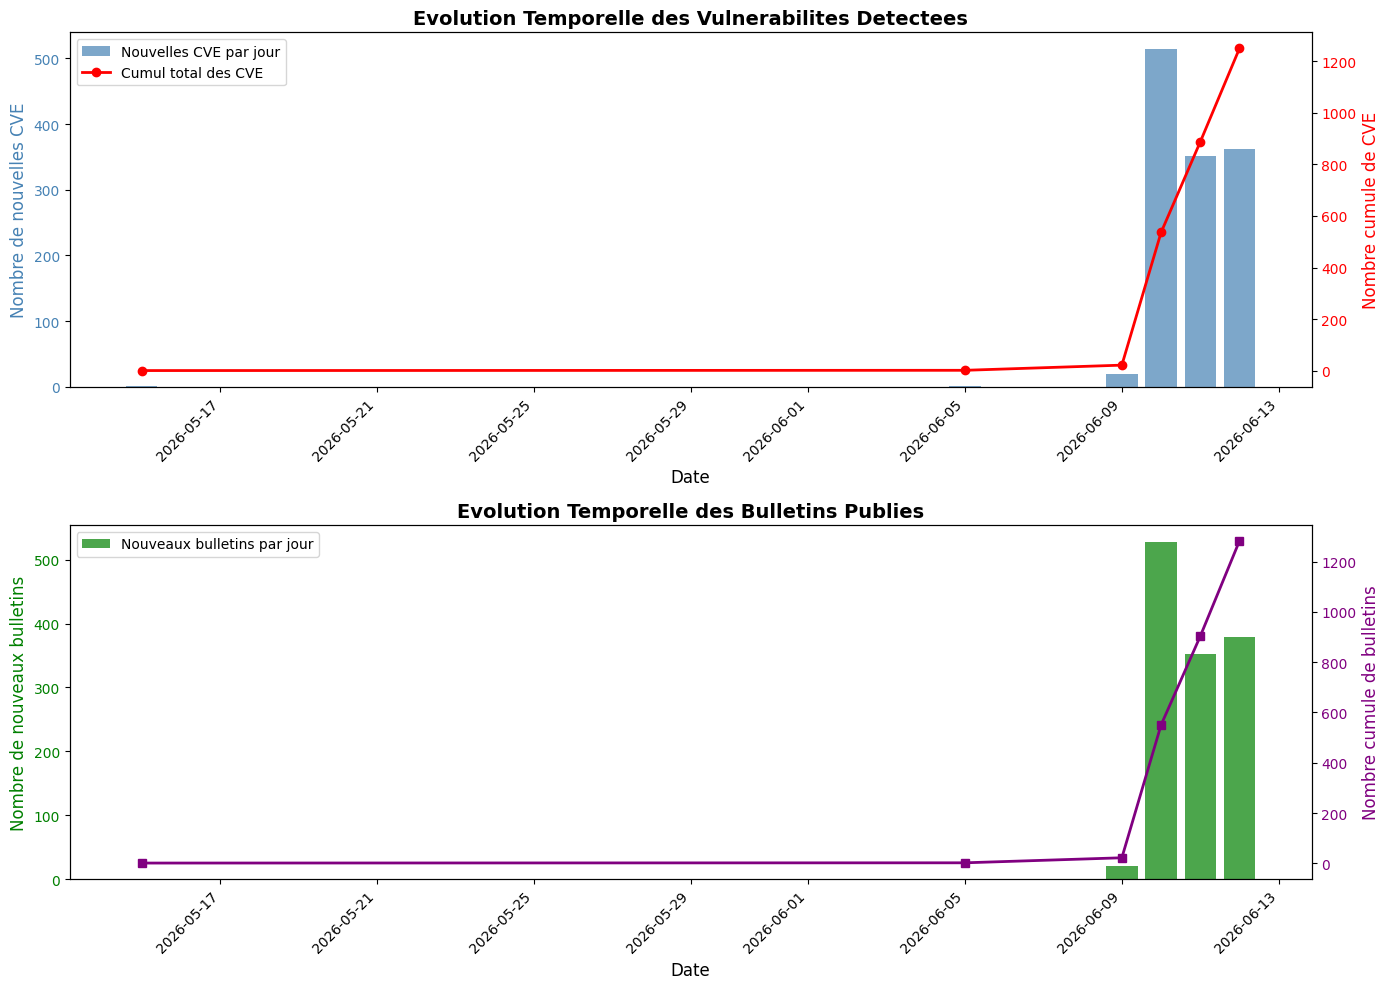

Periode d'analyse: du 2026-05-15 au 2026-06-12
Nombre total de jours: 6
Total CVE uniques sur la periode: 1249
Total bulletins sur la periode: 1282
Moyenne de CVE par jour: 208.2
Jour avec le plus de nouvelles CVE: 2026-06-10 (514 CVE)


In [8]:
#Evolution temporelle cumulative des vulnerabilites

import matplotlib.pyplot as plt
import pandas as pd

# Vérifier que la colonne Date est bien en datetime
if not pd.api.types.is_datetime64_any_dtype(df['Date']):
    print("⚠️ Conversion de la colonne Date en datetime...")
    df['Date'] = pd.to_datetime(df['Date'], format='%a, %d %b %Y %H:%M:%S %z', errors='coerce')
daily_cves = df.groupby(df['Date'].dt.date)['CVE'].nunique().reset_index()
daily_cves.columns = ['Date', 'New_Unique_CVEs']
daily_cves['Cumulative_CVEs'] = daily_cves['New_Unique_CVEs'].cumsum()

# Compter egalement les bulletins par jour
daily_bulletins = df.groupby(df['Date'].dt.date).size().reset_index()
daily_bulletins.columns = ['Date', 'New_Bulletins']
daily_bulletins['Cumulative_Bulletins'] = daily_bulletins['New_Bulletins'].cumsum()

# Creer la figure avec deux sous-graphiques
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Graphique 1: Nouvelles CVE par jour (barres) et cumul (ligne)
ax1 = axes[0]
bars = ax1.bar(daily_cves['Date'], daily_cves['New_Unique_CVEs'], 
               alpha=0.7, label='Nouvelles CVE par jour', color='steelblue')

ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Nombre de nouvelles CVE', fontsize=12, color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.set_title('Evolution Temporelle des Vulnerabilites Detectees', fontsize=14, fontweight='bold')

ax1_twin = ax1.twinx()
ax1_twin.plot(daily_cves['Date'], daily_cves['Cumulative_CVEs'], 
              color='red', marker='o', linewidth=2, label='Cumul total des CVE')
ax1_twin.set_ylabel('Nombre cumule de CVE', fontsize=12, color='red')
ax1_twin.tick_params(axis='y', labelcolor='red')

# Ajouter une legende combinee
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

# Graphique 2: Nouveaux bulletins par jour (barres) et cumul (ligne)
ax2 = axes[1]
ax2.bar(daily_bulletins['Date'], daily_bulletins['New_Bulletins'], 
        alpha=0.7, label='Nouveaux bulletins par jour', color='green')

ax2.set_xlabel('Date', fontsize=12)
ax2.set_ylabel('Nombre de nouveaux bulletins', fontsize=12, color='green')
ax2.tick_params(axis='y', labelcolor='green')
ax2.set_title('Evolution Temporelle des Bulletins Publies', fontsize=14, fontweight='bold')

ax2_twin = ax2.twinx()
ax2_twin.plot(daily_bulletins['Date'], daily_bulletins['Cumulative_Bulletins'], 
              color='purple', marker='s', linewidth=2, label='Cumul total des bulletins')
ax2_twin.set_ylabel('Nombre cumule de bulletins', fontsize=12, color='purple')
ax2_twin.tick_params(axis='y', labelcolor='purple')

ax2.legend(loc='upper left')

# Rotation des dates
for ax in axes:
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha('right')

plt.tight_layout()
plt.show()




print(f"Periode d'analyse: du {daily_cves['Date'].min()} au {daily_cves['Date'].max()}")
print(f"Nombre total de jours: {len(daily_cves)}")
print(f"Total CVE uniques sur la periode: {daily_cves['Cumulative_CVEs'].iloc[-1]}")
print(f"Total bulletins sur la periode: {daily_bulletins['Cumulative_Bulletins'].iloc[-1]}")
print(f"Moyenne de CVE par jour: {daily_cves['New_Unique_CVEs'].mean():.1f}")
print(f"Jour avec le plus de nouvelles CVE: {daily_cves.loc[daily_cves['New_Unique_CVEs'].idxmax(), 'Date']} ({daily_cves['New_Unique_CVEs'].max()} CVE)")

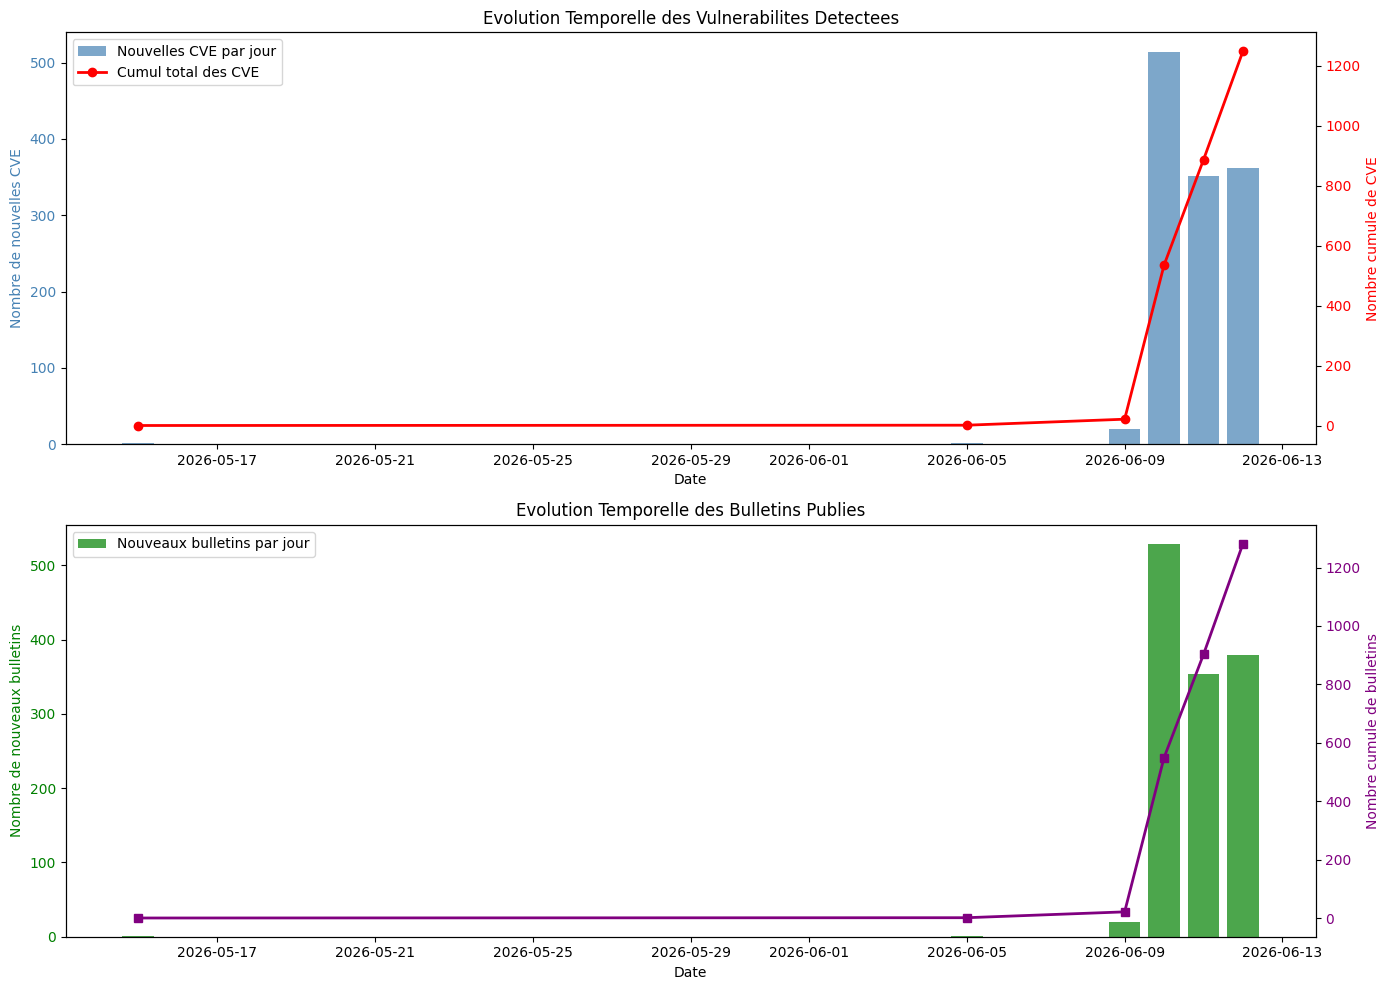

Periode d'analyse: du 2026-05-15 au 2026-06-12
Nombre total de jours: 6
Total CVE uniques sur la periode: 1249
Total bulletins sur la periode: 1282
Moyenne de CVE par jour: 208.2
Jour avec le plus de nouvelles CVE: 2026-06-10 (514 CVE)


In [ ]:
#Evolution temporelle cumulative des vulnerabilites

import matplotlib.pyplot as plt
import pandas as pd


#Vérifier que la colonne Date est bien en datetime
if not pd.api.types.is_datetime64_any_dtype(df['Date']):
    df['Date'] = pd.to_datetime(df['Date'], format='%a, %d %b %Y %H:%M:%S %z', errors='coerce')

#Grouper par jour (uniquement la date, sans l'heure)
daily_cves = df.groupby(df['Date'].dt.date)['CVE'].nunique().reset_index()
daily_cves.columns = ['Date', 'New_Unique_CVEs']
daily_cves['Cumulative_CVEs'] = daily_cves['New_Unique_CVEs'].cumsum()

#Compter également les bulletins par jour
daily_bulletins = df.groupby(df['Date'].dt.date).size().reset_index()
daily_bulletins.columns = ['Date', 'New_Bulletins']
daily_bulletins['Cumulative_Bulletins'] = daily_bulletins['New_Bulletins'].cumsum()



fig, axes = plt.subplots(2, 1, figsize=(14, 10))

#Nouvelles CVE par jour (barres) et cumul (ligne)
ax1 = axes[0]
bars = ax1.bar(daily_cves['Date'], daily_cves['New_Unique_CVEs'], alpha=0.7, label='Nouvelles CVE par jour', color='steelblue')

ax1.set_xlabel('Date')
ax1.set_ylabel('Nombre de nouvelles CVE', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.set_title('Evolution Temporelle des Vulnerabilites Detectees')

ax1_twin = ax1.twinx()
ax1_twin.plot(daily_cves['Date'], daily_cves['Cumulative_CVEs'], color='red', marker='o', linewidth=2, label='Cumul total des CVE')
ax1_twin.set_ylabel('Nombre cumule de CVE', color='red')
ax1_twin.tick_params(axis='y', labelcolor='red')


lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)





#Nouveaux bulletins par jour (barres) et cumul (ligne)
ax2 = axes[1]
ax2.bar(daily_bulletins['Date'], daily_bulletins['New_Bulletins'], 
        alpha=0.7, label='Nouveaux bulletins par jour', color='green')

ax2.set_xlabel('Date')
ax2.set_ylabel('Nombre de nouveaux bulletins', color='green')
ax2.tick_params(axis='y', labelcolor='green')
ax2.set_title('Evolution Temporelle des Bulletins Publies')

ax2_twin = ax2.twinx()
ax2_twin.plot(daily_bulletins['Date'], daily_bulletins['Cumulative_Bulletins'], color='purple', marker='s', linewidth=2, label='Cumul total des bulletins')
ax2_twin.set_ylabel('Nombre cumule de bulletins', color='purple')
ax2_twin.tick_params(axis='y', labelcolor='purple')

ax2.legend(loc='upper left')


plt.tight_layout()
plt.show()



print(f"Periode d'analyse: du {daily_cves['Date'].min()} au {daily_cves['Date'].max()}")
print(f"Nombre total de jours: {len(daily_cves)}")
print(f"Total CVE uniques sur la periode: {daily_cves['Cumulative_CVEs'].iloc[-1]}")
print(f"Total bulletins sur la periode: {daily_bulletins['Cumulative_Bulletins'].iloc[-1]}")
print(f"Moyenne de CVE par jour: {daily_cves['New_Unique_CVEs'].mean():.1f}")
print(f"Jour avec le plus de nouvelles CVE: {daily_cves.loc[daily_cves['New_Unique_CVEs'].idxmax(), 'Date']} ({daily_cves['New_Unique_CVEs'].max()} CVE)")

In [15]:
#Boxplot des scores CVSS par editeur

import matplotlib.pyplot as plt
import seaborn as sns


top_vendors = df['Editeur'].value_counts().head(10).index.tolist()


boxplot_df = df[df['Editeur'].isin(top_vendors) & df['CVSS Score'].notna()]                     #Données non nulles


vendor_counts = boxplot_df['Editeur'].value_counts()
for vendor, count in vendor_counts.items():
    print(f"{vendor:20s}: {count:3d} valeurs CVSS")



fig, ax = plt.subplots(figsize=(14, 7))


sns.boxplot(x = 'Editeur', y = 'CVSS Score', data = boxplot_df, ax = ax, palette = 'viridis')   #x = axis x, y = axis y, data = données utilisées, ax = axe où dessiner

#stripplot = Nuage de points pour données catégorielles
sns.stripplot(x = 'Editeur', y = 'CVSS Score', data = boxplot_df, ax = ax, color = 'black', alpha = 0.3, size = 3, jitter = True) #jitter = dispersion horizontale aléatoire (ajoute du bruit pour éviter la superposition des points)



ax.set_xlabel('Editeur')
ax.set_ylabel('Score CVSS')
ax.set_title('Distribution des Scores CVSS par Editeur (Top 10)')
ax.axhline(y=7, color='orange', linestyle='--', linewidth=1.5, label='Seuil Eleve (7.0)')
ax.axhline(y=9, color='red', linestyle='--', linewidth=1.5, label='Seuil Critique (9.0)')


plt.tight_layout()
plt.show()



for vendor in top_vendors:
    vendor_data = boxplot_df[boxplot_df['Editeur'] == vendor]['CVSS Score']
    if len(vendor_data) > 0:
        print(f"\n{vendor}:")
        print(f"Score CVSS moyen: {vendor_data.mean():.2f}")
        print(f"Score CVSS median: {vendor_data.median():.2f}")
        print(f"Pourcentage de scores critiques (>=9): {(vendor_data >= 9).sum() / len(vendor_data) * 100:.1f}%")
        print(f"Pourcentage de scores eleves (>=7): {(vendor_data >= 7).sum() / len(vendor_data) * 100:.1f}%")

KeyError: 'Editeur'